## Milestone 3

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
data=pd.read_csv("airline_preprocessed.csv",low_memory=False)

## 1. Arrival Delay v/s Busiest Origin 

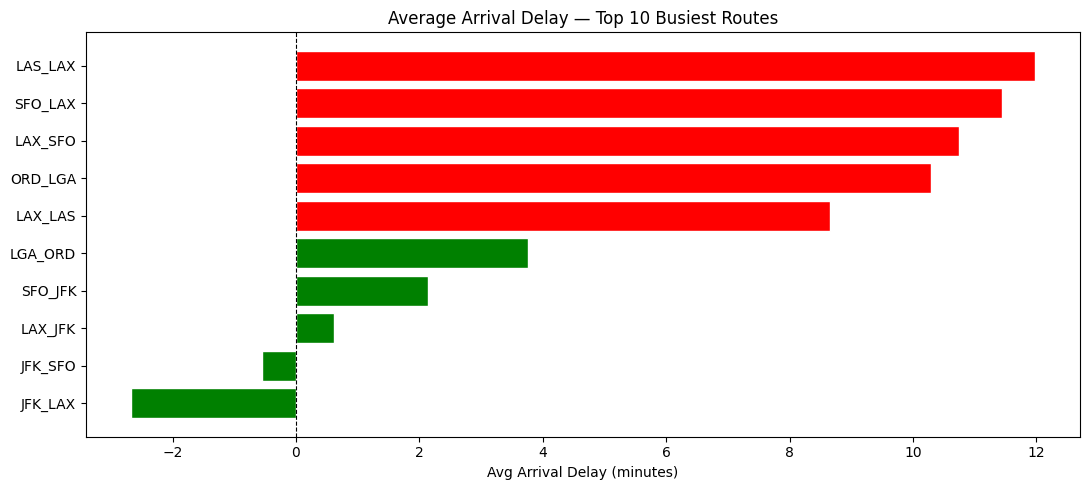

Observation: Busiest routes are NOT the most delayed — high frequency routes are operationally well managed.


In [41]:
route_delay = data[data['CANCELLED']==0].groupby('ROUTE').agg(
    avg_delay=('ARRIVAL_DELAY','mean'),
    flight_count=('ARRIVAL_DELAY','count')
).reset_index()

top10 = data['ROUTE'].value_counts().head(10).index
route_delay = route_delay[route_delay['ROUTE'].isin(top10)].sort_values('avg_delay', ascending=False)

plt.figure(figsize=(11,5))
colors = ['red' if v > 5 else 'green' for v in route_delay['avg_delay']]
plt.barh(route_delay['ROUTE'], route_delay['avg_delay'],
         color=colors, edgecolor='white')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title("Average Arrival Delay — Top 10 Busiest Routes")
plt.xlabel("Avg Arrival Delay (minutes)")
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()
print("Observation: Busiest routes are NOT the most delayed — high frequency routes are operationally well managed.")

## 2.Route Congestion vs Cancellation Rate

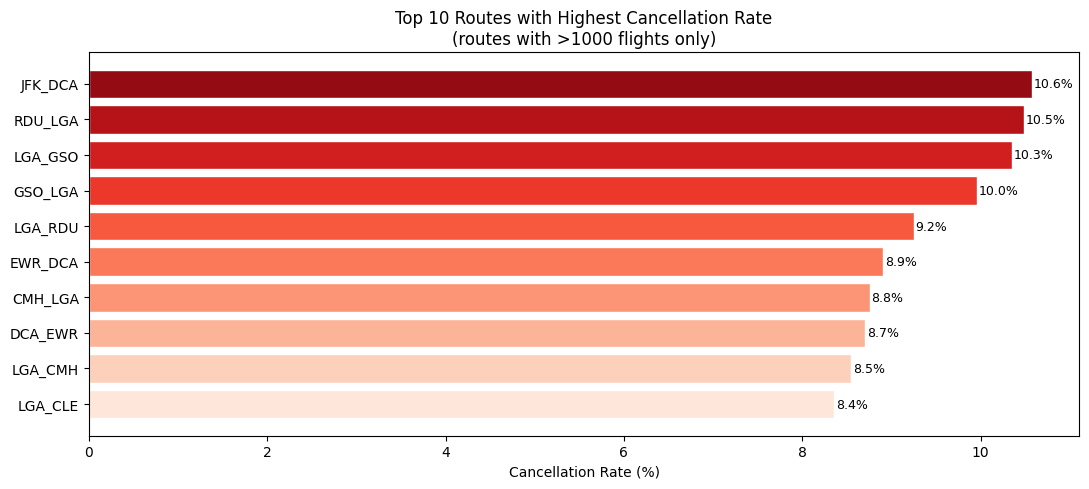

Observation: Routes with highest cancellation rates are predominantly northeast corridor routes — winter weather impact concentrated in specific geographic regions.


In [65]:
route_cancel = data.groupby('ROUTE').agg(
    cancel_rate=('CANCELLED','mean'),
    flight_count=('CANCELLED','count')
).reset_index()

# Only routes with meaningful volume
route_cancel = route_cancel[route_cancel['flight_count'] > 1000]
route_cancel['cancel_pct'] = route_cancel['cancel_rate'] * 100
top10 = route_cancel.nlargest(10, 'cancel_pct')

plt.figure(figsize=(11,5))
colors = sns.color_palette("Reds_r", len(top10))
bars = plt.barh(top10['ROUTE'], top10['cancel_pct'],
                color=colors, edgecolor='white')

# Add value labels
for bar, val in zip(bars, top10['cancel_pct']):
    plt.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)

plt.title("Top 10 Routes with Highest Cancellation Rate\n(routes with >1000 flights only)")
plt.xlabel("Cancellation Rate (%)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("Observation: Routes with highest cancellation rates are predominantly northeast corridor routes — winter weather impact concentrated in specific geographic regions.")

## 3.Cancellation Reason Distribution 

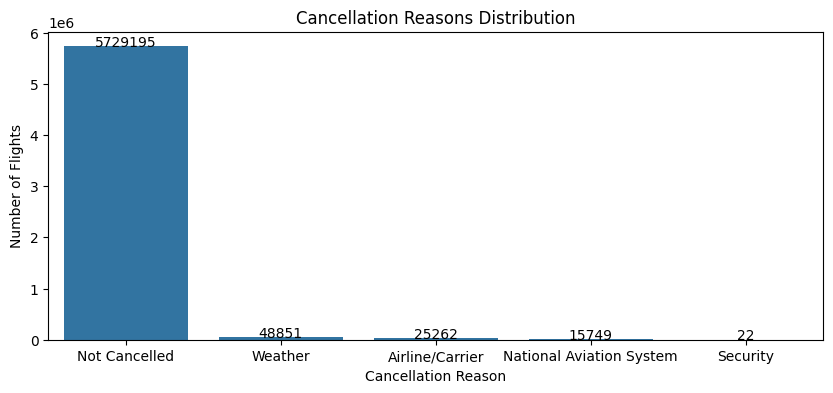

In [21]:
cancel_counts = data['CANCELLATION_REASON'].value_counts()

fig, ax = plt.subplots(figsize=(10,4))

sns.barplot(x=cancel_counts.index, y=cancel_counts.values, ax=ax)

ax.set_title("Cancellation Reasons Distribution")
ax.set_xlabel("Cancellation Reason")
ax.set_ylabel("Number of Flights")

# add value labels
for i, v in enumerate(cancel_counts.values):
    ax.text(i, v + 50, str(v), ha='center')

plt.show()

## 4.Airlines with highest cancellation Rate

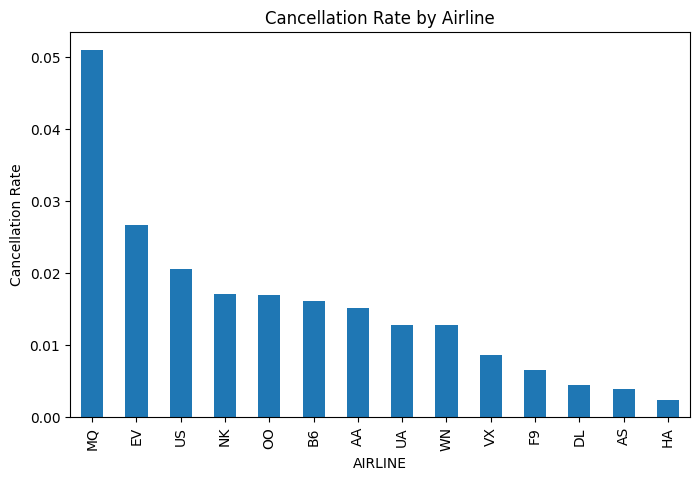

In [38]:
cancel_rate = data.groupby('AIRLINE')['CANCELLED'].mean()

plt.figure(figsize=(8,5))
cancel_rate.sort_values(ascending=False).plot(kind='bar')

plt.title("Cancellation Rate by Airline")
plt.ylabel("Cancellation Rate")
plt.show()

## 5.Cancellation Rate v/s Month

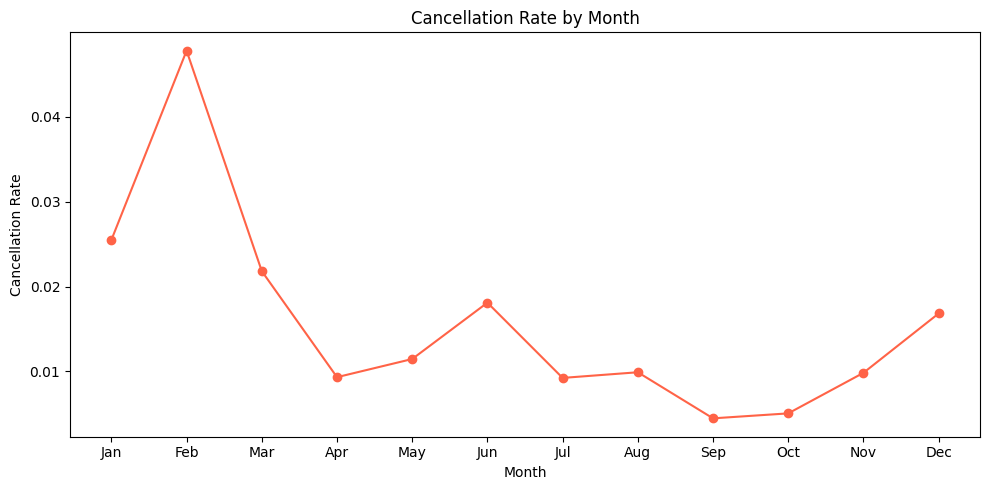

Observation: February has the highest cancellation rate — peak winter storm season. Summer months show lowest cancellation rates despite highest traffic volume.


In [45]:
cancellation_rate = data.groupby('MONTH')['CANCELLED'].mean()
plt.figure(figsize=(10, 5)) 
cancellation_rate.plot(marker='o', color='tomato')
plt.title("Cancellation Rate by Month")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate")
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.tight_layout()
plt.show()
print("Observation: February has the highest cancellation rate — peak winter storm season. Summer months show lowest cancellation rates despite highest traffic volume.")

## 6. Average Arrival Delay By Route x Month

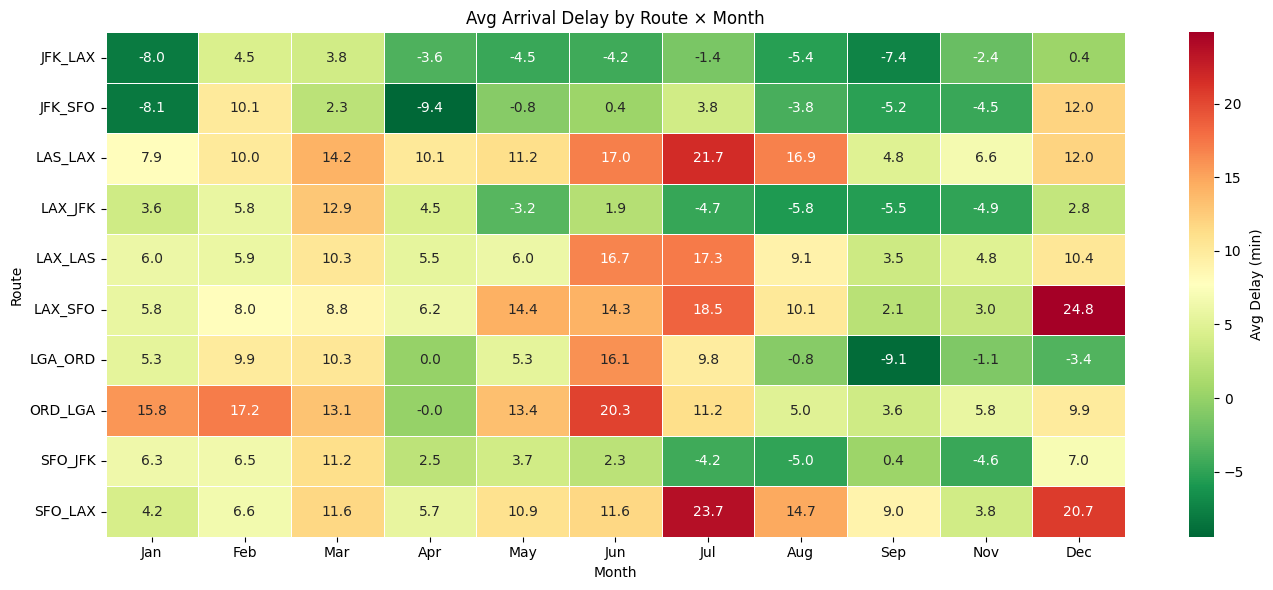

In [28]:
top10_routes = data['ROUTE'].value_counts().head(10).index
subset = data[data['ROUTE'].isin(top10_routes) & (data['CANCELLED']==0)]

pivot = subset.groupby(['ROUTE','MONTH'])['ARRIVAL_DELAY'].mean().unstack()

# Fix — rename only the columns that actually exist
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
pivot.columns = [month_map[c] for c in pivot.columns]  # maps only existing months

plt.figure(figsize=(14,6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label':'Avg Delay (min)'})
plt.title("Avg Arrival Delay by Route × Month")
plt.xlabel("Month")
plt.ylabel("Route")
plt.tight_layout()
plt.show()

## 7.Seasonal Trend Analysis

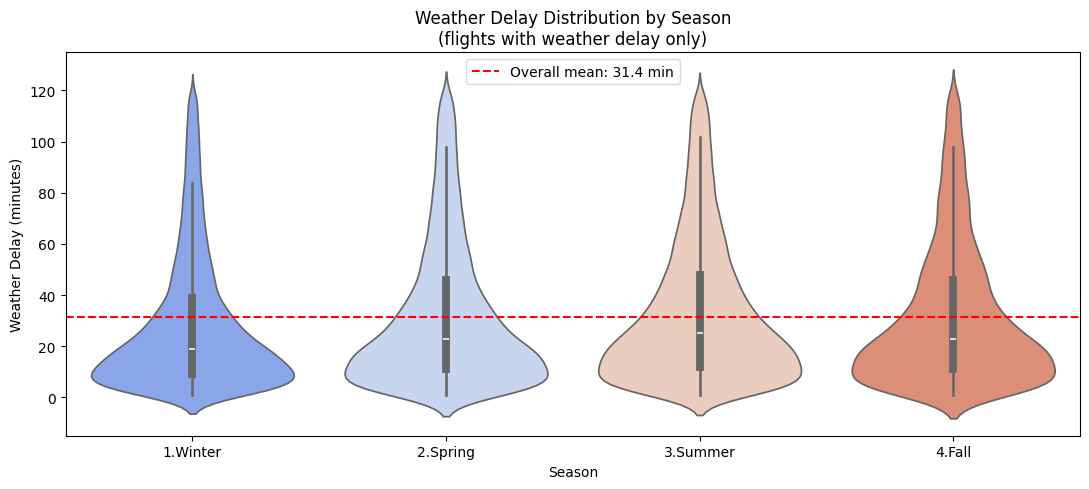

Observation: Winter violin is widest and shifted highest — weather delays in winter are not only more frequent but more severe, with a longer upper tail than any other season.


In [21]:

data['SEASON'] = data['MONTH'].apply(lambda m:
    '1.Winter' if m in [12,1,2] else
    '2.Spring' if m in [3,4,5] else
    '3.Summer' if m in [6,7,8] else '4.Fall')

# Only flights that actually had weather delay
weather_flights = data[
    (data['CANCELLED'] == 0) &
    (data['WEATHER_DELAY'] > 0) &
    (data['WEATHER_DELAY'] < 120)
]

plt.figure(figsize=(11, 5))
sns.violinplot(data=weather_flights, x='SEASON', y='WEATHER_DELAY',
               hue='SEASON', palette='coolwarm', inner='box', legend=False)
plt.axhline(weather_flights['WEATHER_DELAY'].mean(),
            color='red', linestyle='--',
            label=f"Overall mean: {weather_flights['WEATHER_DELAY'].mean():.1f} min")
plt.title("Weather Delay Distribution by Season\n(flights with weather delay only)")
plt.xlabel("Season")
plt.ylabel("Weather Delay (minutes)")
plt.legend()
plt.tight_layout()
plt.show()
print("Observation: Winter violin is widest and shifted highest — weather delays in winter are not only more frequent but more severe, with a longer upper tail than any other season.")

## 8.Monthly Cancellation Trend with reason breakdown

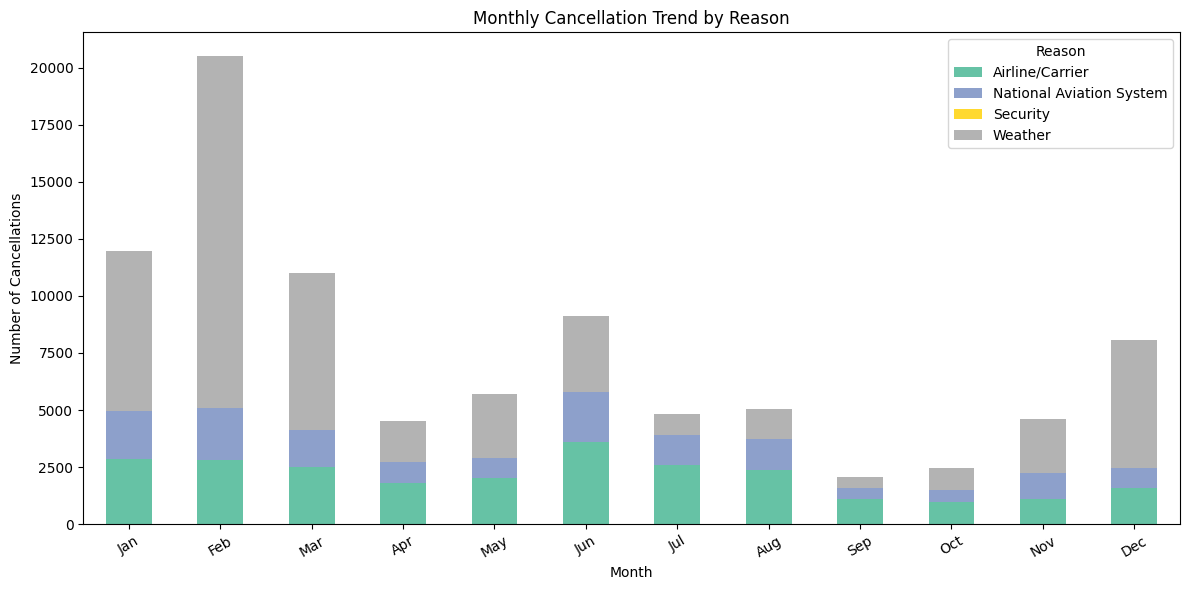

Observation: Weather cancellations spike in Jan-Feb. Carrier cancellations are consistent year round.


In [15]:
monthly_cancel = data[data['CANCELLED']==1].groupby(
    ['MONTH','CANCELLATION_REASON']).size().unstack(fill_value=0)
monthly_cancel.index = ['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_cancel.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set2')
plt.title("Monthly Cancellation Trend by Reason")
plt.ylabel("Number of Cancellations")
plt.xlabel("Month")
plt.xticks(rotation=30)
plt.legend(title="Reason", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()
print("Observation: Weather cancellations spike in Jan-Feb. Carrier cancellations are consistent year round.")

##  9.Winter vs Summer cancellation comparison

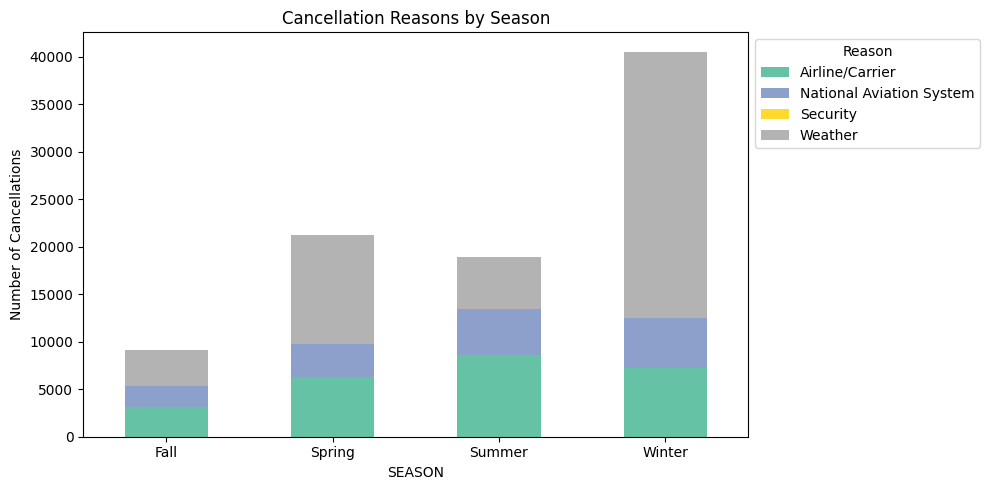

Observation: Winter has 3x more weather cancellations than any other season.


In [19]:
data['SEASON'] = data['MONTH'].apply(lambda m:
    'Winter' if m in [12,1,2] else
    'Summer' if m in [6,7,8] else
    'Spring' if m in [3,4,5] else 'Fall')

season_cancel = data[data['CANCELLED']==1].groupby(
    ['SEASON','CANCELLATION_REASON']).size().unstack(fill_value=0)

season_cancel.plot(kind='bar', stacked=True, figsize=(10,5), colormap='Set2')
plt.title("Cancellation Reasons by Season")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=0)
plt.legend(title="Reason", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()
print("Observation: Winter has 3x more weather cancellations than any other season.")